In [1]:
from multicam_recorder_DataPixx import MultiCameraRecorder
import time
from datetime import datetime

In [2]:
# 1. Setup recorder
recorder = MultiCameraRecorder(
    camera_ids=[0, 1, 2],  # Your cameras
    fps=30,
    trigger=1,
    width=1024,
    height=576,
)

data_dir = '/Users/robertseymour/Documents/recordings/'


ERROR: Invalid device for current operation
INFO:multicam_recorder_DataPixx:DataPixx connection opened, triggers reset to 0
INFO:multicam_recorder_DataPixx:MultiCameraRecorder initialized with cameras: [0, 1, 2], trigger: 1


In [3]:
# 2. Connect to cameras (once)
recorder.connect_cameras()

INFO:multicam_recorder_DataPixx:Connecting to camera 0...
INFO:multicam_recorder_DataPixx:Camera 0 (Camera 0): 1024x576 @ 30fps
INFO:multicam_recorder_DataPixx:Connecting to camera 1...
INFO:multicam_recorder_DataPixx:Camera 1 (Camera 1): 1024x576 @ 30fps
INFO:multicam_recorder_DataPixx:Connecting to camera 2...
INFO:multicam_recorder_DataPixx:Camera 2 (Camera 2): 1024x576 @ 30fps
INFO:multicam_recorder_DataPixx:Connected to 3/3 cameras


{0: True, 1: True, 2: True}

In [ ]:
recorder.preview_cameras(duration=80.0,target_fps=30)

INFO:multicam_recorder_DataPixx:Showing preview for 80.0s at ~30fps (press 'q' to quit)...
INFO:multicam_recorder_DataPixx:Preview resolution: 512x288 (50% of original)


ERROR:multicam_recorder_DataPixx:Camera 1 has too many failures, stopping
ERROR:multicam_recorder_DataPixx:Camera 2 has too many failures, stopping
ERROR:multicam_recorder_DataPixx:Camera 0 has too many failures, stopping


In [5]:
# 3. Record Trial 1
# Get current timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H_%M_%S")

recorder.start_recording(data_dir+'recording_' + timestamp)
time.sleep(20)  # Record for 10 seconds
recorder.stop_recording()

INFO:multicam_recorder_DataPixx:Starting recording: /Users/robertseymour/Documents/recordings/recording_20260217_12_13_34
INFO:multicam_recorder_DataPixx:Camera 0 recording to /Users/robertseymour/Documents/recordings/recording_20260217_12_13_34/raw_videos/camera_0.avi
INFO:multicam_recorder_DataPixx:Camera 1 recording to /Users/robertseymour/Documents/recordings/recording_20260217_12_13_34/raw_videos/camera_1.avi
INFO:multicam_recorder_DataPixx:Camera 2 recording to /Users/robertseymour/Documents/recordings/recording_20260217_12_13_34/raw_videos/camera_2.avi
INFO:multicam_recorder_DataPixx:Camera 3 recording to /Users/robertseymour/Documents/recordings/recording_20260217_12_13_34/raw_videos/camera_3.avi
INFO:multicam_recorder_DataPixx:Sending DataPixx trigger 1 ON
INFO:multicam_recorder_DataPixx:Recording started on 4 cameras
INFO:multicam_recorder_DataPixx:Stopping recording...
INFO:multicam_recorder_DataPixx:Camera 0 stopped recording: 590 frames
INFO:multicam_recorder_DataPixx:Came

{0: (590,
  [1771330414.6944041,
   1771330414.728619,
   1771330414.760921,
   1771330414.7945411,
   1771330414.827472,
   1771330414.859941,
   1771330414.893049,
   1771330414.926116,
   1771330414.958974,
   1771330414.992008,
   1771330415.024714,
   1771330415.0586,
   1771330415.0918112,
   1771330415.124193,
   1771330415.1571321,
   1771330415.19031,
   1771330415.22299,
   1771330415.256075,
   1771330415.289102,
   1771330415.322325,
   1771330415.355357,
   1771330415.388441,
   1771330415.42151,
   1771330415.4865751,
   1771330415.519711,
   1771330415.553181,
   1771330415.586349,
   1771330415.620075,
   1771330415.652601,
   1771330415.6854248,
   1771330415.71898,
   1771330415.7516448,
   1771330415.785035,
   1771330415.8179069,
   1771330415.850365,
   1771330415.8832629,
   1771330415.9166331,
   1771330415.949184,
   1771330415.982157,
   1771330416.0154738,
   1771330416.048532,
   1771330416.081084,
   1771330416.114613,
   1771330416.147659,
   1771330416.180

In [6]:
# 5. Disconnect
recorder.disconnect_cameras()

INFO:multicam_recorder_DataPixx:Disconnecting cameras...
INFO:multicam_recorder_DataPixx:Stopping camera 0...
INFO:multicam_recorder_DataPixx:Camera 0 stopped successfully
INFO:multicam_recorder_DataPixx:Stopping camera 1...
INFO:multicam_recorder_DataPixx:Camera 1 stopped successfully
INFO:multicam_recorder_DataPixx:Stopping camera 2...
INFO:multicam_recorder_DataPixx:Camera 2 stopped successfully
INFO:multicam_recorder_DataPixx:All cameras disconnected successfully
ERROR: Invalid device for current operation
INFO:multicam_recorder_DataPixx:DataPixx connection closed


## Synchronise the Recorded Videos

In [ ]:
from vid_synch import vid_synch, synchronize_videos_to_ideal_fps, plot_sync_results, plot_sync_summary_stats

In [3]:
trial_dir = '/Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_14-15-13'

# # Synchronize all videos to camera 0
# trial_dir = data_dir+'recording_' + timestamp

In [4]:
# Synchronize to ideal 30 FPS (or whatever you specify)
results = synchronize_videos_to_ideal_fps(
    trial_folder=trial_dir,
    target_fps=30.0,  # Your target FPS
    max_time_diff_ms=50.0
)


Timestamp-based Synchronization to Ideal 30.0 FPS Clock
Trial folder: /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_14-15-13
Raw videos:   /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_14-15-13/raw_videos
Output dir:   /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_14-15-13/synchronized_videos
Target FPS:   30.0

[1] Loading timestamps...
  Camera 1: 594 timestamps, range: [1771337713.692, 1771337733.459]s
  Camera 0: 589 timestamps, range: [1771337713.685, 1771337733.316]s

[2] Finding global time range...
  Global start time: 1771337713.692s
  Global end time:   1771337733.316s
  Duration:          19.624s

[3] Creating ideal 30.0 FPS timing grid...
  Ideal frame count: 589
  Ideal duration:    19.600s

[4] Finding video files...
  Camera 0: camera_0.avi
  Camera 1: camera_1.avi

[5] Getting video properties...
  Output FPS:        30.00
  Output resolution: 1024x576 (from camera 0)
  Output frames:     589

[6] Building 

📊 Summary plots saved to: /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_14-15-13/synchronization_plots/sync_summary.png


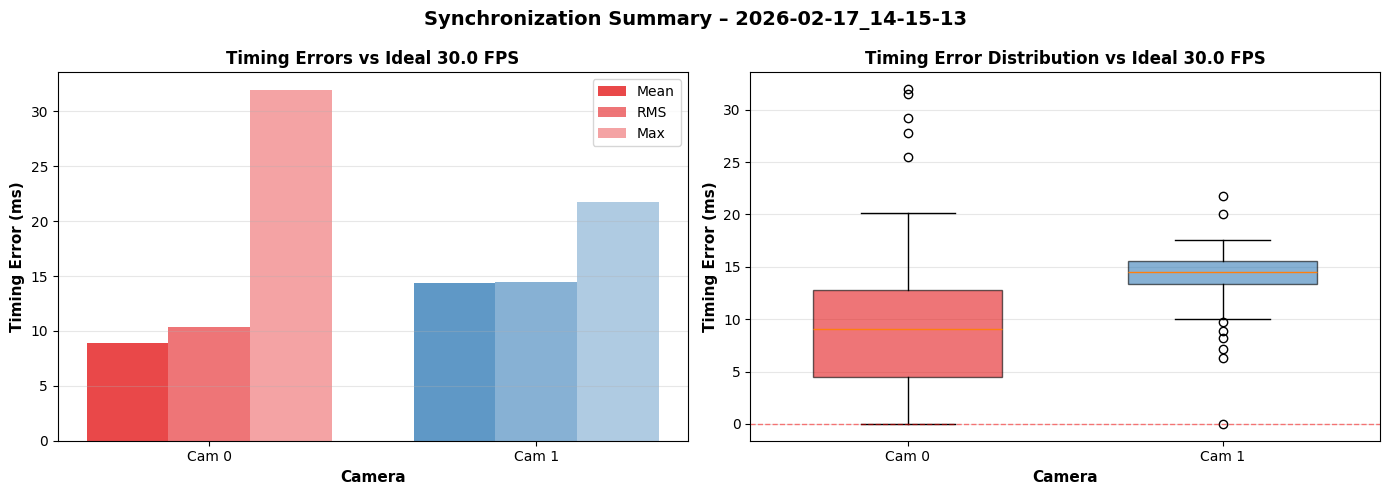

In [ ]:
# Create plots
figs = plot_sync_results(
    results=results,
    trial_folder=trial_dir,
    save_plots=True,
    show_plots=True
)

# Summary stats
fig_summary = plot_sync_summary_stats(
    results=results,
    trial_folder=trial_dir,
    save_plots=True
)

In [12]:
from pathlib import Path
import math

import cv2
import numpy as np


def save_synced_videos_tiled(
    trial_folder,
    synced_subdir="synchronized_videos",
    out_name="synchronized_tiled.mp4",
    max_cols=3,
    max_width=1920,
    pad_px=6,
    pad_value=0,  # black padding
    font_scale=0.9,
    thickness=2,
):
    """
    Tile synchronized videos into a single review video (grid layout).

    - Auto-wrap: up to `max_cols` per row (default 3), then starts a new row.
    - Assumes synchronized and identical frame counts (still checks).
    - Input filenames: camera_<id>_synchronized.mp4

    Output is MP4 (H.264 if available, else mp4v).
    """
    trial_folder = Path(trial_folder)
    synced_dir = trial_folder / synced_subdir
    out_path = trial_folder / out_name

    videos = sorted(synced_dir.glob("camera_*_synchronized.mp4"))
    if not videos:
        raise FileNotFoundError(f"No synchronized videos found in {synced_dir}")

    caps = []
    cam_ids = []
    for v in videos:
        cap = cv2.VideoCapture(str(v))
        if not cap.isOpened():
            raise RuntimeError(f"Could not open {v}")
        caps.append(cap)
        cam_ids.append(int(v.stem.split("_")[1]))

    # --- checks ---
    frame_counts = [int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) for cap in caps]
    if len(set(frame_counts)) != 1:
        raise ValueError(f"Frame count mismatch: {dict(zip(cam_ids, frame_counts))}")

    fps = caps[0].get(cv2.CAP_PROP_FPS) or 25.0
    n_frames = frame_counts[0]

    # Determine a common cell size (max width/height across cameras)
    widths = [int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) for cap in caps]
    heights = [int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) for cap in caps]
    cell_w = max(widths)
    cell_h = max(heights)

    n = len(caps)
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)

    grid_w = cols * cell_w + (cols - 1) * pad_px
    grid_h = rows * cell_h + (rows - 1) * pad_px

    # Optional downscale to fit screen width
    scale = 1.0
    if max_width and grid_w > max_width:
        scale = max_width / grid_w

    out_w = int(round(grid_w * scale))
    out_h = int(round(grid_h * scale))

    # Choose codec: try H.264 first (often works as 'avc1' on mac, 'H264' on some builds)
    def _make_writer(codec):
        fourcc = cv2.VideoWriter_fourcc(*codec)
        w = cv2.VideoWriter(str(out_path), fourcc, fps, (out_w, out_h))
        return w

    writer = _make_writer("avc1")
    if not writer.isOpened():
        writer = _make_writer("H264")
    if not writer.isOpened():
        writer = _make_writer("mp4v")
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for {out_path}")

    print("Writing tiled video:")
    print(f"  cameras: {cam_ids}")
    print(f"  videos:  {n} -> grid {rows}x{cols}")
    print(f"  frames:  {n_frames}")
    print(f"  fps:     {fps:.2f}")
    print(f"  cell:    {cell_w}x{cell_h} px")
    print(f"  output:  {out_path}")

    # Reset all captures to frame 0
    for cap in caps:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    # --- write ---
    for i in range(n_frames):
        # Start with a blank grid canvas
        canvas = np.full((grid_h, grid_w, 3), pad_value, dtype=np.uint8)

        for idx, (cam_id, cap) in enumerate(zip(cam_ids, caps)):
            ok, frame = cap.read()
            if not ok:
                raise RuntimeError(f"Failed reading frame {i} from camera {cam_id}")

            # Resize into cell (letterbox to preserve aspect ratio)
            fh, fw = frame.shape[:2]
            s = min(cell_w / fw, cell_h / fh)
            new_w = int(round(fw * s))
            new_h = int(round(fh * s))
            resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)

            cell = np.full((cell_h, cell_w, 3), pad_value, dtype=np.uint8)
            y0 = (cell_h - new_h) // 2
            x0 = (cell_w - new_w) // 2
            cell[y0:y0 + new_h, x0:x0 + new_w] = resized

            # overlay text (on the cell)
            cv2.putText(
                cell,
                f"Cam {cam_id} | frame {i}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                (0, 255, 0),
                thickness,
                cv2.LINE_AA,
            )

            r = idx // cols
            c = idx % cols
            top = r * (cell_h + pad_px)
            left = c * (cell_w + pad_px)
            canvas[top:top + cell_h, left:left + cell_w] = cell

        # Final scale (if needed)
        if scale != 1.0:
            canvas = cv2.resize(canvas, (out_w, out_h), interpolation=cv2.INTER_AREA)

        writer.write(canvas)

    # cleanup
    writer.release()
    for cap in caps:
        cap.release()

    print("Done ✅")
    return out_path


In [15]:
# ---- usage ----
out_video = save_synced_videos_tiled(trial_dir)
out_video

Writing tiled video:
  cameras: [0, 1, 2, 3]
  videos:  4 -> grid 2x3
  frames:  599
  fps:     30.00
  cell:    1280x720 px
  output:  /Users/robertseymour/Documents/recordings/recording_20260210_16_04_07/synchronized_tiled.mp4
Done ✅


PosixPath('/Users/robertseymour/Documents/recordings/recording_20260210_16_04_07/synchronized_tiled.mp4')